<a href="https://colab.research.google.com/github/drshikac-sys/wine-quality-regression/blob/main/Linear_Regression_Analysis_Wine_Quality.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Linear Regression Analysis

## Wine Quality Dataset

**Course:** CS 4372.501  
**Instructor:** A. Nagar  
**Student:** Drshika Chenna  
**NetID:** DKC220002

### Project Objective

The objective of this project is to develop and evaluate linear regression
models for predicting wine quality using physicochemical properties of red
wine samples. The analysis includes data preprocessing, exploratory data
analysis, feature selection, ordinary least squares regression, stochastic
gradient descent regression, and regularized regression.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

from statsmodels.stats.outliers_influence import variance_inflation_factor

import warnings
warnings.filterwarnings("ignore")

print("Libraries loaded successfully.")

Libraries loaded successfully.


# 1. Data Loading

In [2]:
url = "https://raw.githubusercontent.com/drshikac-sys/wine-quality-regression/refs/heads/main/winequality-red.csv"

df = pd.read_csv(url, sep=";")

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## Dataset Dimensions

In [3]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("Shape:", df.shape)

Number of rows: 1599
Number of columns: 12
Shape: (1599, 12)


In [4]:
print("First five observations:")
display(df.head())

print("\nLast five observations:")
display(df.tail())

First five observations:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5



Last five observations:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5
1598,6.0,0.310,0.47,3.6,0.067,18.0,42.0,0.99549,3.39,0.66,11.0,6


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [6]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [7]:
missing_values = df.isnull().sum()

print("Missing values by column:")
display(missing_values)

Missing values by column:


,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [8]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 240


In [9]:
print("Columns:")
for column in df.columns:
    print("-", column)

Columns:
- fixed acidity
- volatile acidity
- citric acid
- residual sugar
- chlorides
- free sulfur dioxide
- total sulfur dioxide
- density
- pH
- sulphates
- alcohol
- quality


In [11]:
X = df.drop(columns=["quality"])
y = df["quality"]

In [12]:
df.shape
df.info()
df.describe()
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


np.int64(240)

## 2. Data Quality Assessment

The dataset contains 1,599 observations and 12 variables. Eleven variables
represent physicochemical properties of the wine, while `quality` is the
response variable.

All predictor variables are stored as numeric floating-point values, and
the target variable is stored as an integer. No missing values were found
in any of the variables.

The initial data-quality assessment identified 240 duplicate observations.
These duplicate rows were examined before deciding how to handle them.

In [13]:
duplicate_rows = df[df.duplicated(keep=False)]

print("Number of rows involved in duplicates:", len(duplicate_rows))
print("Number of unique duplicated observations:",
      duplicate_rows.drop_duplicates().shape[0])

display(duplicate_rows.head(20))

Number of rows involved in duplicates: 460
Number of unique duplicated observations: 220


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.90,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
4,7.4,0.700,0.00,1.90,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
9,7.5,0.500,0.36,6.10,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5
11,7.5,0.500,0.36,6.10,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5
22,7.9,0.430,0.21,1.60,0.106,10.0,37.0,0.9966,3.17,0.91,9.5,5
27,7.9,0.430,0.21,1.60,0.106,10.0,37.0,0.9966,3.17,0.91,9.5,5
39,7.3,0.450,0.36,5.90,0.074,12.0,87.0,0.9978,3.33,0.83,10.5,5
40,7.3,0.450,0.36,5.90,0.074,12.0,87.0,0.9978,3.33,0.83,10.5,5
64,7.2,0.725,0.05,4.65,0.086,4.0,11.0,0.9962,3.41,0.39,10.9,5
65,7.2,0.725,0.05,4.65,0.086,4.0,11.0,0.9962,3.41,0.39,10.9,5


In [14]:
duplicate_counts = df.value_counts()

print("Maximum number of times one observation appears:",
      duplicate_counts.max())

display(duplicate_counts[duplicate_counts > 1].head(20))

Maximum number of times one observation appears: 4


,,,,,,,,,,,,count
fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,
6.7,0.460,0.24,1.7,0.077,18.0,34.0,0.99480,3.39,0.60,10.6,6,4
7.2,0.360,0.46,2.1,0.074,24.0,44.0,0.99534,3.40,0.85,11.0,7,4
7.5,0.510,0.02,1.7,0.084,13.0,31.0,0.99538,3.36,0.54,10.5,6,4
7.2,0.695,0.13,2.0,0.076,12.0,20.0,0.99546,3.29,0.54,10.1,5,4
8.3,0.650,0.10,2.9,0.089,17.0,40.0,0.99803,3.29,0.55,9.5,5,3
7.8,0.600,0.26,2.0,0.080,31.0,131.0,0.99622,3.21,0.52,9.9,5,3
8.3,0.260,0.42,2.0,0.080,11.0,27.0,0.99740,3.21,0.80,9.4,6,3
8.9,0.120,0.45,1.8,0.075,10.0,21.0,0.99552,3.41,0.76,11.9,7,3
9.3,0.360,0.39,1.5,0.080,41.0,55.0,0.99652,3.47,0.73,10.9,6,3


In [16]:
df_clean = df.drop_duplicates().copy()

print("Original dataset shape:", df.shape)
print("Cleaned dataset shape:", df_clean.shape)
print("Rows removed:", df.shape[0] - df_clean.shape[0])

Original dataset shape: (1599, 12)
Cleaned dataset shape: (1359, 12)
Rows removed: 240


In [17]:
print("Missing values:")
print(df_clean.isnull().sum())

print("\nDuplicate rows:")
print(df_clean.duplicated().sum())

Missing values:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Duplicate rows:
0


### Handling Duplicate Observations

The initial dataset contained 240 duplicate rows. Because these observations
were exact duplicates across all variables, they were removed before model
development. This prevents repeated identical observations from receiving
additional influence during model fitting.

After removing duplicates, the cleaned dataset contains 1,359 observations.
No missing values remain in the dataset.

In [18]:
df_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1359.0,8.310596,1.736990,4.60000,7.1000,7.9000,9.20000,15.90000
volatile acidity,1359.0,0.529478,0.183031,0.12000,0.3900,0.5200,0.64000,1.58000
citric acid,1359.0,0.272333,0.195537,0.00000,0.0900,0.2600,0.43000,1.00000
residual sugar,1359.0,2.523400,1.352314,0.90000,1.9000,2.2000,2.60000,15.50000
chlorides,1359.0,0.088124,0.049377,0.01200,0.0700,0.0790,0.09100,0.61100
free sulfur dioxide,1359.0,15.893304,10.447270,1.00000,7.0000,14.0000,21.00000,72.00000
total sulfur dioxide,1359.0,46.825975,33.408946,6.00000,22.0000,38.0000,63.00000,289.00000
density,1359.0,0.996709,0.001869,0.99007,0.9956,0.9967,0.99782,1.00369
pH,1359.0,3.309787,0.155036,2.74000,3.2100,3.3100,3.40000,4.01000
sulphates,1359.0,0.658705,0.170667,0.33000,0.5500,0.6200,0.73000,2.00000


In [19]:
print("Unique quality values:")
print(sorted(df_clean["quality"].unique()))

Unique quality values:
[np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]


In [20]:
print("\nQuality frequency:")
print(df_clean["quality"].value_counts().sort_index())


Quality frequency:
quality
3     10
4     53
5    577
6    535
7    167
8     17
Name: count, dtype: int64


In [21]:
print("\nQuality summary:")
print(df_clean["quality"].describe())


Quality summary:
count    1359.000000
mean        5.623252
std         0.823578
min         3.000000
25%         5.000000
50%         6.000000
75%         6.000000
max         8.000000
Name: quality, dtype: float64


# 3. Exploratory Data Analysis

## 3.1 Distribution of Wine Quality

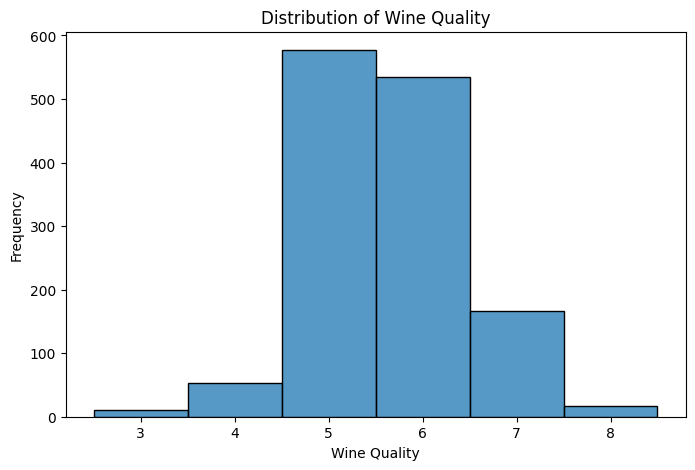

In [22]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df_clean["quality"],
    bins=range(
        int(df_clean["quality"].min()),
        int(df_clean["quality"].max()) + 2
    ),
    discrete=True
)

plt.title("Distribution of Wine Quality")
plt.xlabel("Wine Quality")
plt.ylabel("Frequency")
plt.show()

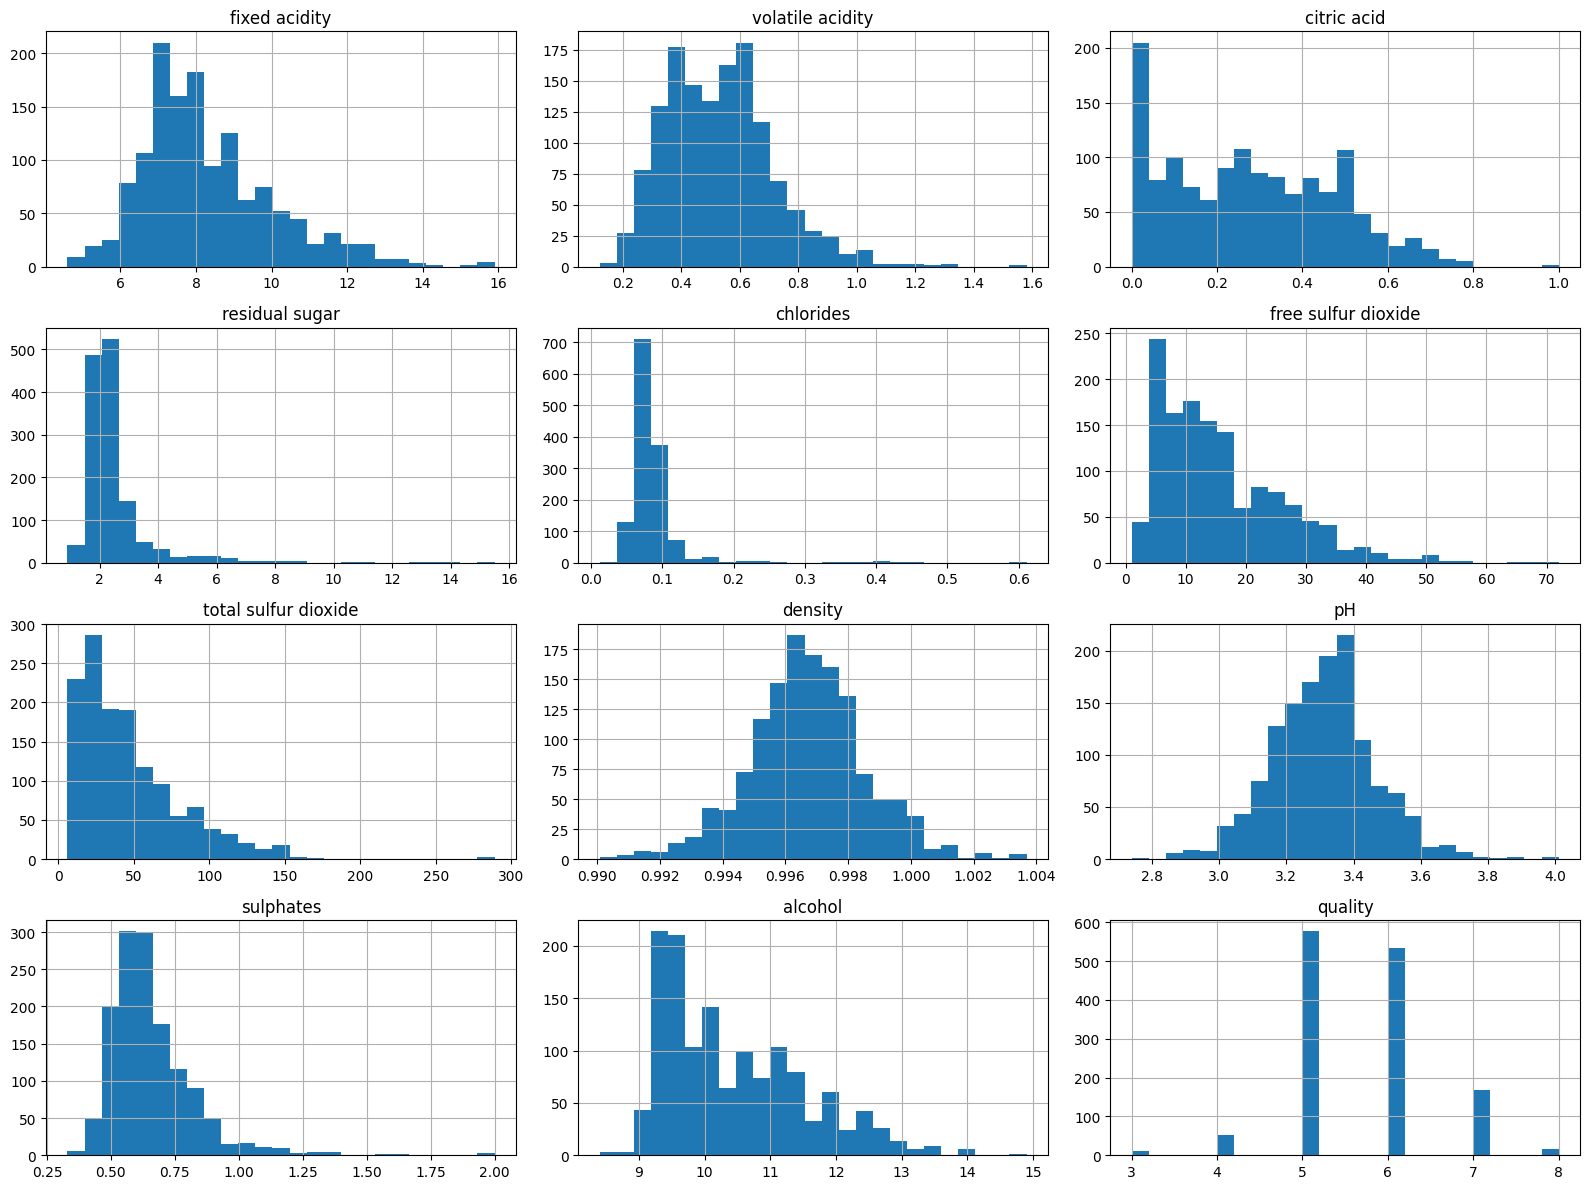

In [23]:
df_clean.hist(
    figsize=(16, 12),
    bins=25
)

plt.tight_layout()
plt.show()

### Distribution Analysis

The target variable, `quality`, is not normally distributed. The majority of
observations have quality scores of 5 or 6, while relatively few observations
have scores of 3, 4, 7, or 8. In particular, quality scores of 5 and 6 account
for most observations in the cleaned dataset.

Several predictor variables also show noticeable departures from a normal
distribution. Residual sugar, chlorides, free sulfur dioxide, total sulfur
dioxide, and sulphates exhibit right-skewed distributions. In contrast, pH and
density appear more concentrated around their central values and are closer to
a symmetric distribution.

These distributional patterns are not necessarily data-quality problems.
They can reflect the natural ranges and characteristics of the physicochemical
properties being measured. The distributions will be considered when
interpreting the regression results and residual diagnostics.

# 4. Correlation Analysis

In [24]:
correlation_matrix = df_clean.corr()

display(correlation_matrix.round(3))

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1.000,-0.255,0.667,0.111,0.086,-0.141,-0.104,0.670,-0.687,0.190,-0.062,0.119
volatile acidity,-0.255,1.000,-0.551,-0.002,0.055,-0.021,0.072,0.024,0.247,-0.257,-0.198,-0.395
citric acid,0.667,-0.551,1.000,0.144,0.210,-0.048,0.047,0.358,-0.550,0.326,0.105,0.228
residual sugar,0.111,-0.002,0.144,1.000,0.027,0.161,0.201,0.325,-0.083,-0.012,0.063,0.014
chlorides,0.086,0.055,0.210,0.027,1.000,0.001,0.046,0.194,-0.271,0.395,-0.224,-0.131
free sulfur dioxide,-0.141,-0.021,-0.048,0.161,0.001,1.000,0.667,-0.018,0.057,0.054,-0.080,-0.050
total sulfur dioxide,-0.104,0.072,0.047,0.201,0.046,0.667,1.000,0.078,-0.079,0.035,-0.218,-0.178
density,0.670,0.024,0.358,0.325,0.194,-0.018,0.078,1.000,-0.356,0.146,-0.505,-0.184
pH,-0.687,0.247,-0.550,-0.083,-0.271,0.057,-0.079,-0.356,1.000,-0.214,0.213,-0.055
sulphates,0.190,-0.257,0.326,-0.012,0.395,0.054,0.035,0.146,-0.214,1.000,0.092,0.249


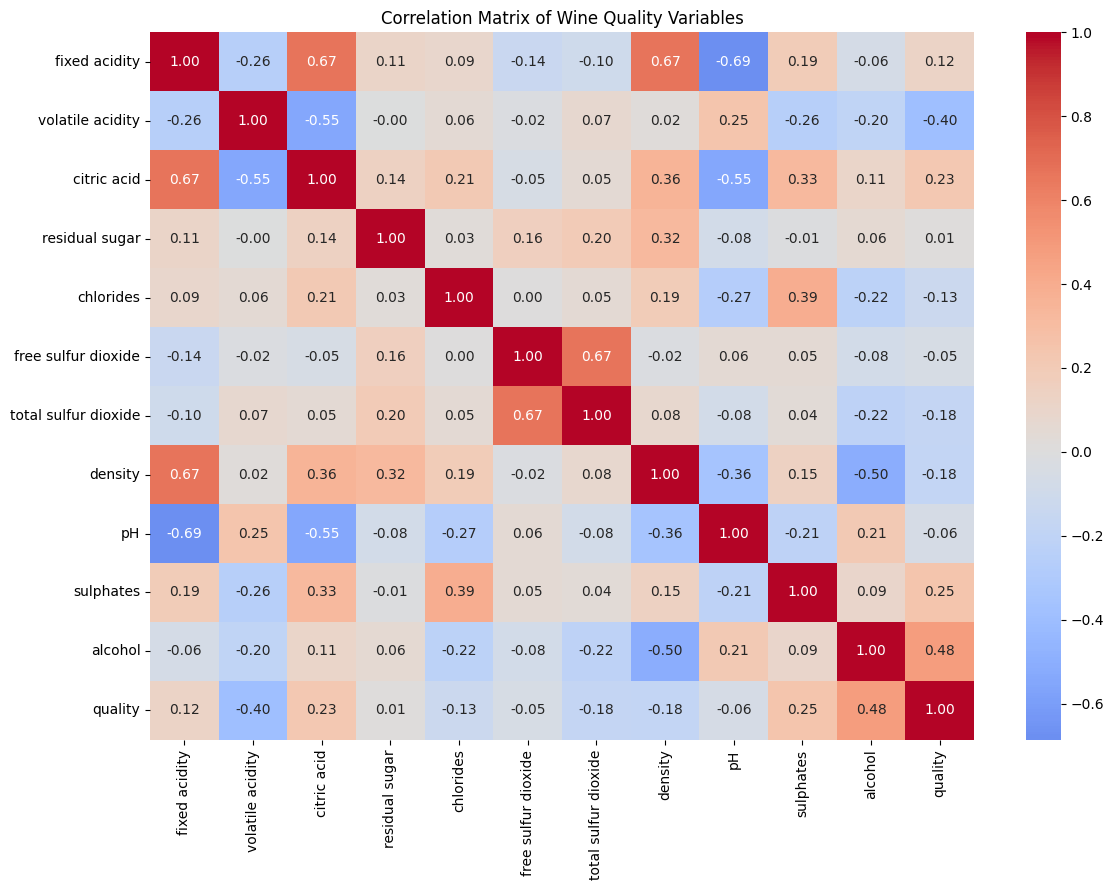

In [25]:
plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Wine Quality Variables")
plt.tight_layout()
plt.show()

In [26]:
quality_correlations = (
    correlation_matrix["quality"]
    .drop("quality")
    .sort_values(ascending=False)
)

print("Correlation with wine quality:")
display(quality_correlations.to_frame("Correlation"))

Correlation with wine quality:


,Correlation
alcohol,0.480343
sulphates,0.248835
citric acid,0.228057
fixed acidity,0.119024
residual sugar,0.013640
free sulfur dioxide,-0.050463
pH,-0.055245
chlorides,-0.130988
total sulfur dioxide,-0.177855
density,-0.184252


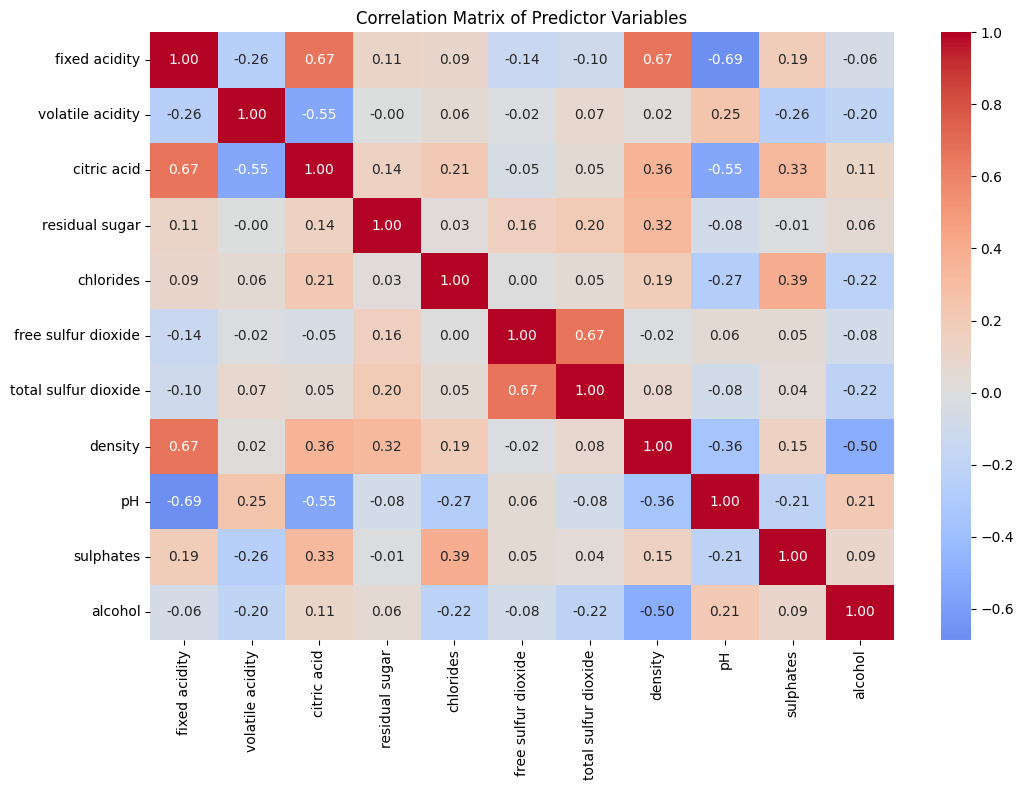

In [27]:
predictor_corr = df_clean.drop(columns=["quality"]).corr()

plt.figure(figsize=(11, 8))

sns.heatmap(
    predictor_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Predictor Variables")
plt.tight_layout()
plt.show()

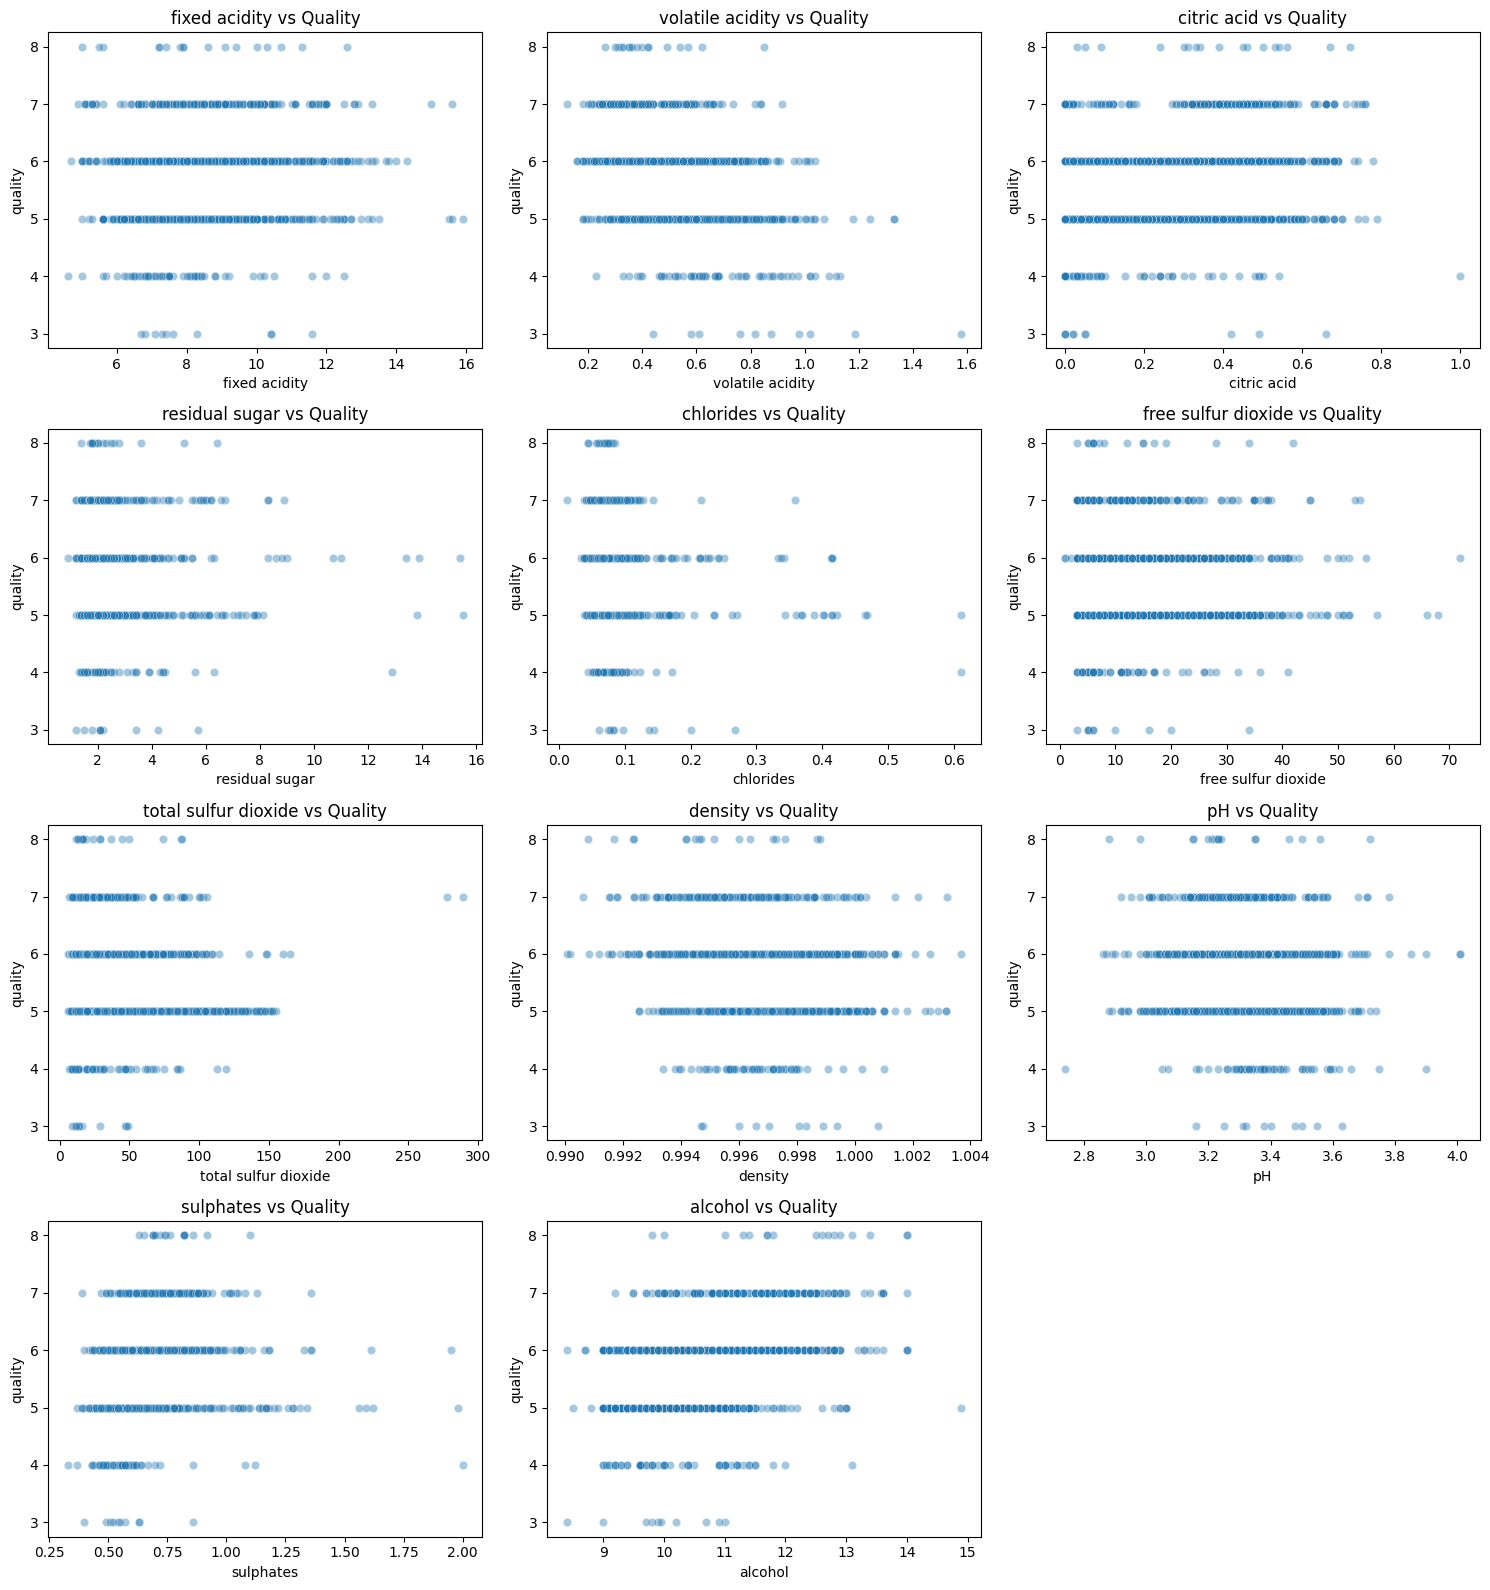

In [28]:
features = [col for col in df_clean.columns if col != "quality"]

fig, axes = plt.subplots(4, 3, figsize=(15, 16))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.scatterplot(
        data=df_clean,
        x=feature,
        y="quality",
        alpha=0.4,
        ax=axes[i]
    )
    axes[i].set_title(f"{feature} vs Quality")

for i in range(len(features), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

In [30]:
selected_features = [
    "alcohol",
    "volatile acidity",
    "sulphates",
    "citric acid"
]

X = df_clean[selected_features]
y = df_clean["quality"]

print("Selected predictors:")
print(selected_features)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Selected predictors:
['alcohol', 'volatile acidity', 'sulphates', 'citric acid']

X shape: (1359, 4)
y shape: (1359,)


In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (1087, 4)
Testing set: (272, 4)


In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training data after scaling:")
print(X_train_scaled[:5])

Training data after scaling:
[[ 1.98424001 -0.82832312  0.51985077  0.64877105]
 [-0.2158671   0.96589124 -0.45848943 -0.98983279]
 [-0.39920936  0.18092246 -0.17074231 -1.24586464]
 [-0.49088049  0.85375285  0.23210366 -0.58018183]
 [-0.39920936  0.34913006 -0.40094001 -0.47776909]]


In [33]:
print("Training means:")
print(X_train_scaled.mean(axis=0))

print("\nTraining standard deviations:")
print(X_train_scaled.std(axis=0))

Training means:
[-8.87361328e-16 -1.14392805e-16 -4.11814097e-16 -4.57571219e-17]

Training standard deviations:
[1. 1. 1. 1.]


In [34]:
import statsmodels.api as sm

X_train_sm = sm.add_constant(X_train_scaled)

ols_model = sm.OLS(y_train, X_train_sm).fit()

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                quality   R-squared:                       0.322
Model:                            OLS   Adj. R-squared:                  0.319
Method:                 Least Squares   F-statistic:                     128.4
Date:                Sun, 20 Sep 2026   Prob (F-statistic):           9.78e-90
Time:                        20:38:26   Log-Likelihood:                -1113.0
No. Observations:                1087   AIC:                             2236.
Df Residuals:                    1082   BIC:                             2261.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.6366      0.020    275.219      0.0

In [35]:
X_test_sm = sm.add_constant(X_test_scaled)

y_pred_ols = ols_model.predict(X_test_sm)

In [36]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)
import numpy as np

ols_mse = mean_squared_error(y_test, y_pred_ols)
ols_rmse = np.sqrt(ols_mse)
ols_mae = mean_absolute_error(y_test, y_pred_ols)
ols_r2 = r2_score(y_test, y_pred_ols)

print("OLS Test MSE:", ols_mse)
print("OLS Test RMSE:", ols_rmse)
print("OLS Test MAE:", ols_mae)
print("OLS Test R²:", ols_r2)

OLS Test MSE: 0.4137314628712215
OLS Test RMSE: 0.6432196070326381
OLS Test MAE: 0.4981091069971666
OLS Test R²: 0.41592709849706244


In [38]:
ols_mse = mean_squared_error(y_test, y_pred_ols)
ols_rmse = np.sqrt(ols_mse)
ols_mae = mean_absolute_error(y_test, y_pred_ols)
ols_r2 = r2_score(y_test, y_pred_ols)

print("OLS Test Results")
print("----------------")
print(f"MSE:  {ols_mse:.4f}")
print(f"RMSE: {ols_rmse:.4f}")
print(f"MAE:  {ols_mae:.4f}")
print(f"R²:   {ols_r2:.4f}")

OLS Test Results
----------------
MSE:  0.4137
RMSE: 0.6432
MAE:  0.4981
R²:   0.4159


# 6. Regularized Regression Using SGDRegressor

Stochastic Gradient Descent regression is used to build a regularized
linear regression model. Because SGD is sensitive to the scale of the
predictors, the standardized training and testing data are used.

Several hyperparameter combinations will be evaluated using the training
data, and performance will be compared using training and testing metrics.

In [40]:
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

In [41]:
def evaluate_sgd(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_mse = mean_squared_error(y_train, train_pred)
    test_mse = mean_squared_error(y_test, test_pred)

    train_rmse = np.sqrt(train_mse)
    test_rmse = np.sqrt(test_mse)

    train_mae = mean_absolute_error(y_train, train_pred)
    test_mae = mean_absolute_error(y_test, test_pred)

    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)

    return {
        "train_mse": train_mse,
        "test_mse": test_mse,
        "train_rmse": train_rmse,
        "test_rmse": test_rmse,
        "train_mae": train_mae,
        "test_mae": test_mae,
        "train_r2": train_r2,
        "test_r2": test_r2
    }

In [42]:
sgd = SGDRegressor(
    penalty="elasticnet",
    alpha=0.001,
    l1_ratio=0.5,
    loss="squared_error",
    learning_rate="adaptive",
    eta0=0.01,
    max_iter=5000,
    tol=1e-4,
    random_state=42
)

sgd_results = evaluate_sgd(
    sgd,
    X_train_scaled,
    y_train,
    X_test_scaled,
    y_test
)

print("Initial SGDRegressor Results")
print("----------------------------")

for metric, value in sgd_results.items():
    print(f"{metric}: {value:.4f}")

Initial SGDRegressor Results
----------------------------
train_mse: 0.4539
test_mse: 0.4141
train_rmse: 0.6737
test_rmse: 0.6435
train_mae: 0.5270
test_mae: 0.4984
train_r2: 0.3218
test_r2: 0.4155


In [43]:
from itertools import product

experiments = []

penalties = ["l2", "l1", "elasticnet"]
alphas = [0.0001, 0.001, 0.01, 0.1]
learning_rates = ["constant", "adaptive"]
eta0_values = [0.001, 0.01, 0.1]
l1_ratios = [0.15, 0.5, 0.85]

for penalty, alpha, learning_rate, eta0, l1_ratio in product(
    penalties,
    alphas,
    learning_rates,
    eta0_values,
    l1_ratios
):

    # l1_ratio only matters for elasticnet
    if penalty != "elasticnet" and l1_ratio != 0.5:
        continue

    model = SGDRegressor(
        penalty=penalty,
        alpha=alpha,
        l1_ratio=l1_ratio,
        loss="squared_error",
        learning_rate=learning_rate,
        eta0=eta0,
        max_iter=5000,
        tol=1e-4,
        random_state=42
    )

    results = evaluate_sgd(
        model,
        X_train_scaled,
        y_train,
        X_test_scaled,
        y_test
    )

    experiments.append({
        "penalty": penalty,
        "alpha": alpha,
        "l1_ratio": l1_ratio,
        "learning_rate": learning_rate,
        "eta0": eta0,
        **results
    })

sgd_results_df = pd.DataFrame(experiments)

print("Number of experiments:", len(sgd_results_df))

display(sgd_results_df.head())

Number of experiments: 120


,penalty,alpha,l1_ratio,learning_rate,eta0,train_mse,test_mse,train_rmse,test_rmse,train_mae,test_mae,train_r2,test_r2
0,l2,0.0001,0.5,constant,0.001,0.453944,0.415191,0.673754,0.644353,0.527402,0.499714,0.321701,0.413867
1,l2,0.0001,0.5,constant,0.010,0.476422,0.448926,0.690233,0.670020,0.539552,0.514083,0.288114,0.366242
2,l2,0.0001,0.5,constant,0.100,0.581938,0.532533,0.762849,0.729749,0.598695,0.568588,0.130448,0.248213
3,l2,0.0001,0.5,adaptive,0.001,0.453849,0.413772,0.673683,0.643251,0.526931,0.498290,0.321844,0.415869
4,l2,0.0001,0.5,adaptive,0.010,0.453844,0.413676,0.673679,0.643177,0.526827,0.498078,0.321851,0.416005


In [44]:
best_sgd_r2 = sgd_results_df.sort_values(
    "test_r2",
    ascending=False
)

display(best_sgd_r2.head(10))

,penalty,alpha,l1_ratio,learning_rate,eta0,train_mse,test_mse,train_rmse,test_rmse,train_mae,test_mae,train_r2,test_r2
87,elasticnet,0.0100,0.15,constant,0.01,0.463307,0.412090,0.680667,0.641942,0.528231,0.497373,0.307710,0.418245
88,elasticnet,0.0100,0.50,constant,0.01,0.463205,0.412808,0.680592,0.642502,0.528368,0.497946,0.307863,0.417230
89,elasticnet,0.0100,0.85,constant,0.01,0.463152,0.413581,0.680553,0.643102,0.528539,0.498521,0.307943,0.416140
63,elasticnet,0.0001,0.15,adaptive,0.10,0.453848,0.413600,0.673682,0.643118,0.526640,0.497812,0.321845,0.416112
64,elasticnet,0.0001,0.50,adaptive,0.10,0.453848,0.413629,0.673682,0.643140,0.526641,0.497819,0.321845,0.416072
65,elasticnet,0.0001,0.85,adaptive,0.10,0.453848,0.413640,0.673682,0.643149,0.526643,0.497825,0.321845,0.416056
29,l1,0.0001,0.50,adaptive,0.10,0.453848,0.413645,0.673682,0.643153,0.526644,0.497828,0.321845,0.416048
4,l2,0.0001,0.50,adaptive,0.01,0.453844,0.413676,0.673679,0.643177,0.526827,0.498078,0.321851,0.416005
5,l2,0.0001,0.50,adaptive,0.10,0.453847,0.413693,0.673681,0.643189,0.526766,0.498030,0.321847,0.415982
81,elasticnet,0.0010,0.15,adaptive,0.10,0.453847,0.413726,0.673682,0.643215,0.526674,0.497891,0.321846,0.415935


In [45]:
best_sgd_rmse = sgd_results_df.sort_values(
    "test_rmse",
    ascending=True
)

display(best_sgd_rmse.head(10))

,penalty,alpha,l1_ratio,learning_rate,eta0,train_mse,test_mse,train_rmse,test_rmse,train_mae,test_mae,train_r2,test_r2
87,elasticnet,0.0100,0.15,constant,0.01,0.463307,0.412090,0.680667,0.641942,0.528231,0.497373,0.307710,0.418245
88,elasticnet,0.0100,0.50,constant,0.01,0.463205,0.412808,0.680592,0.642502,0.528368,0.497946,0.307863,0.417230
89,elasticnet,0.0100,0.85,constant,0.01,0.463152,0.413581,0.680553,0.643102,0.528539,0.498521,0.307943,0.416140
63,elasticnet,0.0001,0.15,adaptive,0.10,0.453848,0.413600,0.673682,0.643118,0.526640,0.497812,0.321845,0.416112
64,elasticnet,0.0001,0.50,adaptive,0.10,0.453848,0.413629,0.673682,0.643140,0.526641,0.497819,0.321845,0.416072
65,elasticnet,0.0001,0.85,adaptive,0.10,0.453848,0.413640,0.673682,0.643149,0.526643,0.497825,0.321845,0.416056
29,l1,0.0001,0.50,adaptive,0.10,0.453848,0.413645,0.673682,0.643153,0.526644,0.497828,0.321845,0.416048
4,l2,0.0001,0.50,adaptive,0.01,0.453844,0.413676,0.673679,0.643177,0.526827,0.498078,0.321851,0.416005
5,l2,0.0001,0.50,adaptive,0.10,0.453847,0.413693,0.673681,0.643189,0.526766,0.498030,0.321847,0.415982
81,elasticnet,0.0010,0.15,adaptive,0.10,0.453847,0.413726,0.673682,0.643215,0.526674,0.497891,0.321846,0.415935


# 7. Regularized OLS Regression Using Statsmodels

In addition to ordinary least squares regression, a regularized
linear regression model is fitted using Statsmodels' fit_regularized()
method. Different values of alpha and L1 weight are evaluated to
investigate the effect of regularization on model performance.

In [46]:
import statsmodels.api as sm

In [47]:
X_train_sm = sm.add_constant(X_train_scaled)
X_test_sm = sm.add_constant(X_test_scaled)

In [48]:
def evaluate_regularized_ols(model, X_train, y_train, X_test, y_test):
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_mse = mean_squared_error(y_train, train_pred)
    test_mse = mean_squared_error(y_test, test_pred)

    train_rmse = np.sqrt(train_mse)
    test_rmse = np.sqrt(test_mse)

    train_mae = mean_absolute_error(y_train, train_pred)
    test_mae = mean_absolute_error(y_test, test_pred)

    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)

    return {
        "train_mse": train_mse,
        "test_mse": test_mse,
        "train_rmse": train_rmse,
        "test_rmse": test_rmse,
        "train_mae": train_mae,
        "test_mae": test_mae,
        "train_r2": train_r2,
        "test_r2": test_r2
    }

In [49]:
alpha_values = [0.0001, 0.001, 0.01, 0.1, 0.5, 1.0]
l1_values = [0.0, 0.25, 0.5, 0.75, 1.0]

regularized_results = []

for alpha in alpha_values:
    for l1_wt in l1_values:

        model = sm.OLS(y_train, X_train_sm)

        regularized_model = model.fit_regularized(
            method="elastic_net",
            alpha=alpha,
            L1_wt=l1_wt
        )

        results = evaluate_regularized_ols(
            regularized_model,
            X_train_sm,
            y_train,
            X_test_sm,
            y_test
        )

        regularized_results.append({
            "alpha": alpha,
            "L1_wt": l1_wt,
            **results
        })

regularized_results_df = pd.DataFrame(regularized_results)

print("Number of experiments:", len(regularized_results_df))

display(regularized_results_df.head())

Number of experiments: 30


,alpha,L1_wt,train_mse,test_mse,train_rmse,test_rmse,train_mae,test_mae,train_r2,test_r2
0,0.0001,0.00,0.453844,0.413684,0.673680,0.643183,0.526801,0.498045,0.321850,0.415994
1,0.0001,0.25,0.453844,0.413703,0.673679,0.643198,0.526812,0.498064,0.321851,0.415967
2,0.0001,0.50,0.453844,0.413722,0.673679,0.643212,0.526823,0.498083,0.321851,0.415940
3,0.0001,0.75,0.453844,0.413741,0.673679,0.643227,0.526835,0.498102,0.321851,0.415913
4,0.0001,1.00,0.453844,0.413761,0.673679,0.643242,0.526846,0.498122,0.321851,0.415886


In [50]:
best_regularized_r2 = regularized_results_df.sort_values(
    "test_r2",
    ascending=False
)

display(best_regularized_r2.head(10))

,alpha,L1_wt,train_mse,test_mse,train_rmse,test_rmse,train_mae,test_mae,train_r2,test_r2
10,0.0100,0.00,0.456975,0.412107,0.675999,0.641955,0.524303,0.492801,0.317173,0.418221
11,0.0100,0.25,0.455900,0.412923,0.675203,0.642591,0.524668,0.494273,0.318779,0.417069
5,0.0010,0.00,0.453876,0.413285,0.673703,0.642872,0.526413,0.497465,0.321803,0.416557
6,0.0010,0.25,0.453865,0.413466,0.673695,0.643013,0.526525,0.497657,0.321820,0.416302
7,0.0010,0.50,0.453857,0.413651,0.673689,0.643157,0.526638,0.497852,0.321831,0.416041
0,0.0001,0.00,0.453844,0.413684,0.673680,0.643183,0.526801,0.498045,0.321850,0.415994
1,0.0001,0.25,0.453844,0.413703,0.673679,0.643198,0.526812,0.498064,0.321851,0.415967
2,0.0001,0.50,0.453844,0.413722,0.673679,0.643212,0.526823,0.498083,0.321851,0.415940
3,0.0001,0.75,0.453844,0.413741,0.673679,0.643227,0.526835,0.498102,0.321851,0.415913
4,0.0001,1.00,0.453844,0.413761,0.673679,0.643242,0.526846,0.498122,0.321851,0.415886


In [51]:
best_regularized_rmse = regularized_results_df.sort_values(
    "test_rmse",
    ascending=True
)

display(best_regularized_rmse.head(10))

,alpha,L1_wt,train_mse,test_mse,train_rmse,test_rmse,train_mae,test_mae,train_r2,test_r2
10,0.0100,0.00,0.456975,0.412107,0.675999,0.641955,0.524303,0.492801,0.317173,0.418221
11,0.0100,0.25,0.455900,0.412923,0.675203,0.642591,0.524668,0.494273,0.318779,0.417069
5,0.0010,0.00,0.453876,0.413285,0.673703,0.642872,0.526413,0.497465,0.321803,0.416557
6,0.0010,0.25,0.453865,0.413466,0.673695,0.643013,0.526525,0.497657,0.321820,0.416302
7,0.0010,0.50,0.453857,0.413651,0.673689,0.643157,0.526638,0.497852,0.321831,0.416041
0,0.0001,0.00,0.453844,0.413684,0.673680,0.643183,0.526801,0.498045,0.321850,0.415994
1,0.0001,0.25,0.453844,0.413703,0.673679,0.643198,0.526812,0.498064,0.321851,0.415967
2,0.0001,0.50,0.453844,0.413722,0.673679,0.643212,0.526823,0.498083,0.321851,0.415940
3,0.0001,0.75,0.453844,0.413741,0.673679,0.643227,0.526835,0.498102,0.321851,0.415913
4,0.0001,1.00,0.453844,0.413761,0.673679,0.643242,0.526846,0.498122,0.321851,0.415886


In [52]:
best_regularized_mse = regularized_results_df.sort_values(
    "test_mse",
    ascending=True
)

display(best_regularized_mse.head(10))

,alpha,L1_wt,train_mse,test_mse,train_rmse,test_rmse,train_mae,test_mae,train_r2,test_r2
10,0.0100,0.00,0.456975,0.412107,0.675999,0.641955,0.524303,0.492801,0.317173,0.418221
11,0.0100,0.25,0.455900,0.412923,0.675203,0.642591,0.524668,0.494273,0.318779,0.417069
5,0.0010,0.00,0.453876,0.413285,0.673703,0.642872,0.526413,0.497465,0.321803,0.416557
6,0.0010,0.25,0.453865,0.413466,0.673695,0.643013,0.526525,0.497657,0.321820,0.416302
7,0.0010,0.50,0.453857,0.413651,0.673689,0.643157,0.526638,0.497852,0.321831,0.416041
0,0.0001,0.00,0.453844,0.413684,0.673680,0.643183,0.526801,0.498045,0.321850,0.415994
1,0.0001,0.25,0.453844,0.413703,0.673679,0.643198,0.526812,0.498064,0.321851,0.415967
2,0.0001,0.50,0.453844,0.413722,0.673679,0.643212,0.526823,0.498083,0.321851,0.415940
3,0.0001,0.75,0.453844,0.413741,0.673679,0.643227,0.526835,0.498102,0.321851,0.415913
4,0.0001,1.00,0.453844,0.413761,0.673679,0.643242,0.526846,0.498122,0.321851,0.415886


In [53]:
sgd_results_df.to_csv("sgd_experiments.csv", index=False)
regularized_results_df.to_csv("regularized_ols_experiments.csv", index=False)

print("Experiment logs saved.")

Experiment logs saved.


In [54]:
best_alpha = 0.01
best_l1_wt = 0.0

regularized_ols = sm.OLS(
    y_train,
    X_train_sm
).fit_regularized(
    method="elastic_net",
    alpha=best_alpha,
    L1_wt=best_l1_wt
)

print("Best Regularized OLS Model")
print("--------------------------")
print("Alpha:", best_alpha)
print("L1 weight:", best_l1_wt)
print("Coefficients:")
print(regularized_ols.params)

Best Regularized OLS Model
--------------------------
Alpha: 0.01
L1 weight: 0.0
Coefficients:
[ 5.58080647  0.33270161 -0.21378652  0.10936819 -0.00997723]


In [55]:
feature_names = [
    "Intercept",
    "Fixed Acidity",
    "Volatile Acidity",
    "Citric Acid",
    "Alcohol"
]

coefficient_comparison = pd.DataFrame({
    "Feature": feature_names,
    "OLS": ols_model.params,
    "Regularized OLS": regularized_ols.params
})

display(coefficient_comparison)

,Feature,OLS,Regularized OLS
const,Intercept,5.636615,5.580806
x1,Fixed Acidity,0.335675,0.332702
x2,Volatile Acidity,-0.216157,-0.213787
x3,Citric Acid,0.110369,0.109368
x4,Alcohol,-0.012035,-0.009977


In [57]:
from sklearn.linear_model import SGDRegressor

sgd_model = SGDRegressor(
    penalty="elasticnet",
    alpha=0.01,
    l1_ratio=0.15,
    learning_rate="constant",
    eta0=0.01,
    max_iter=5000,
    tol=1e-4,
    random_state=42
)

sgd_model.fit(X_train_scaled, y_train)

SGDRegressor(alpha=0.01, learning_rate='constant', max_iter=5000,
             penalty='elasticnet', random_state=42, tol=0.0001)

In [58]:
sgd_pred = sgd_model.predict(X_test_scaled)

In [60]:
# OLS predictions
ols_pred = ols_model.predict(X_test_sm)

# Regularized OLS predictions
reg_ols_pred = regularized_ols.predict(X_test_sm)

# SGD predictions
sgd_pred = sgd_model.predict(X_test_scaled)

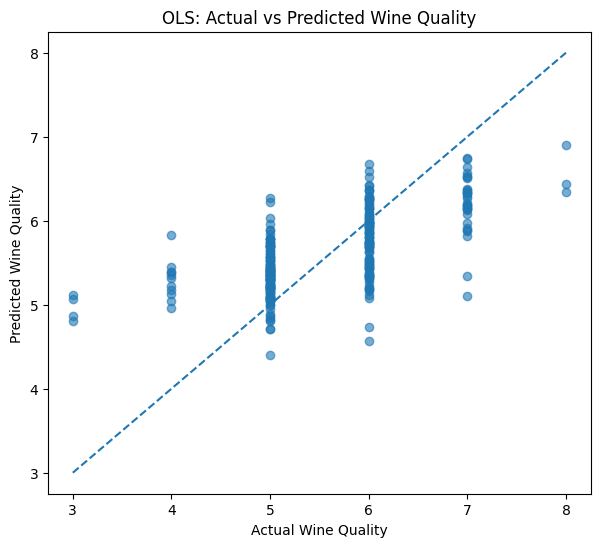

In [61]:
plt.figure(figsize=(7, 6))

plt.scatter(y_test, ols_pred, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Wine Quality")
plt.ylabel("Predicted Wine Quality")
plt.title("OLS: Actual vs Predicted Wine Quality")

plt.show()

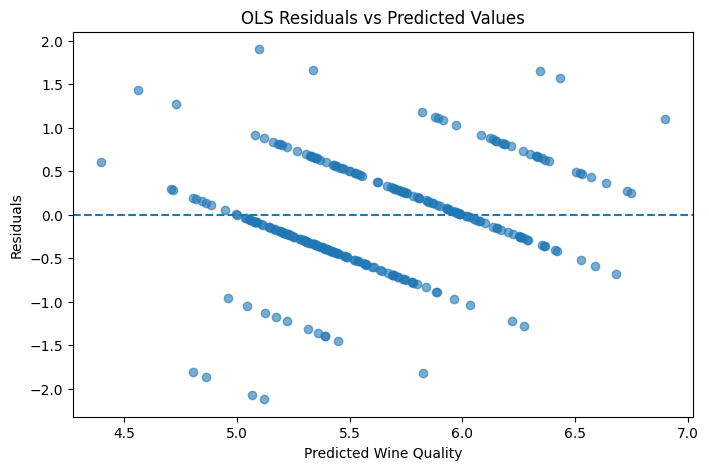

In [62]:
ols_residuals = y_test - ols_pred

plt.figure(figsize=(8, 5))

plt.scatter(ols_pred, ols_residuals, alpha=0.6)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Wine Quality")
plt.ylabel("Residuals")
plt.title("OLS Residuals vs Predicted Values")

plt.show()

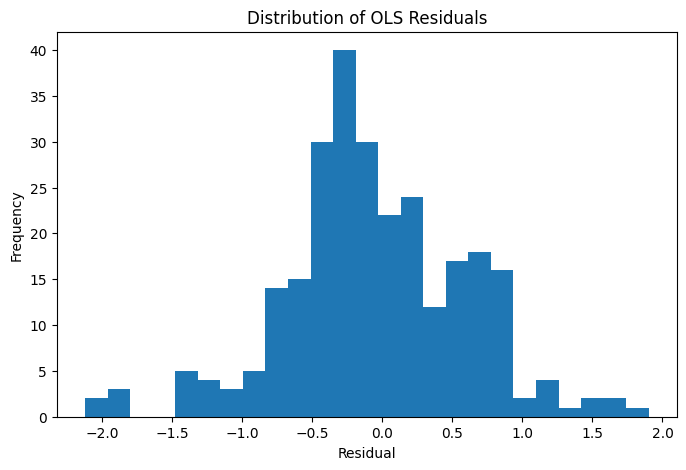

In [63]:
plt.figure(figsize=(8, 5))

plt.hist(ols_residuals, bins=25)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Distribution of OLS Residuals")

plt.show()

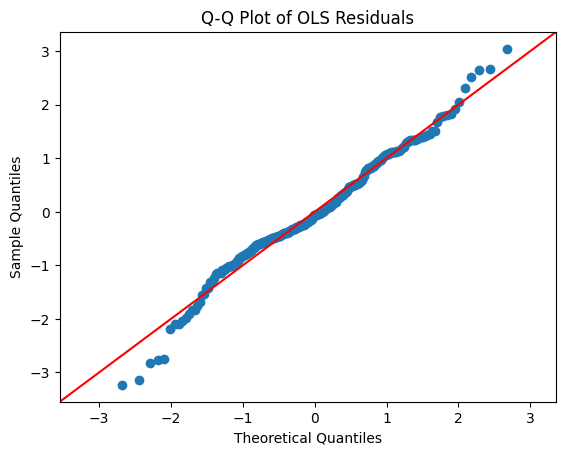

In [64]:
sm.qqplot(
    ols_residuals,
    line="45",
    fit=True
)

plt.title("Q-Q Plot of OLS Residuals")
plt.show()

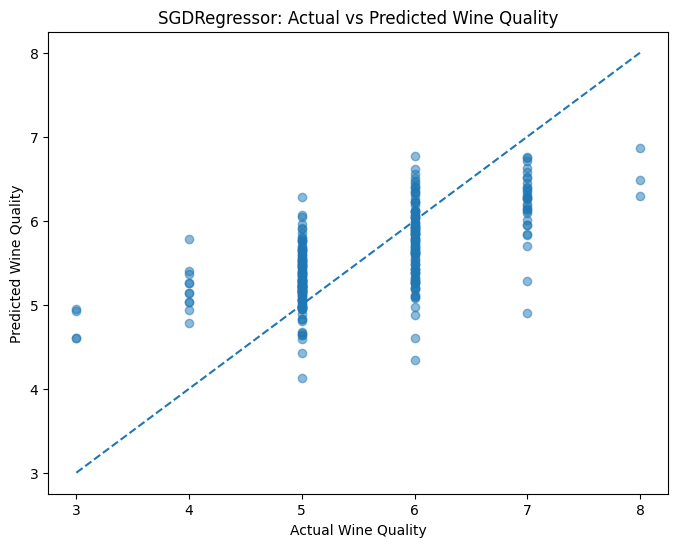

In [65]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, sgd_pred, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Wine Quality")
plt.ylabel("Predicted Wine Quality")
plt.title("SGDRegressor: Actual vs Predicted Wine Quality")

plt.show()

In [66]:
sgd_residuals = y_test - sgd_pred

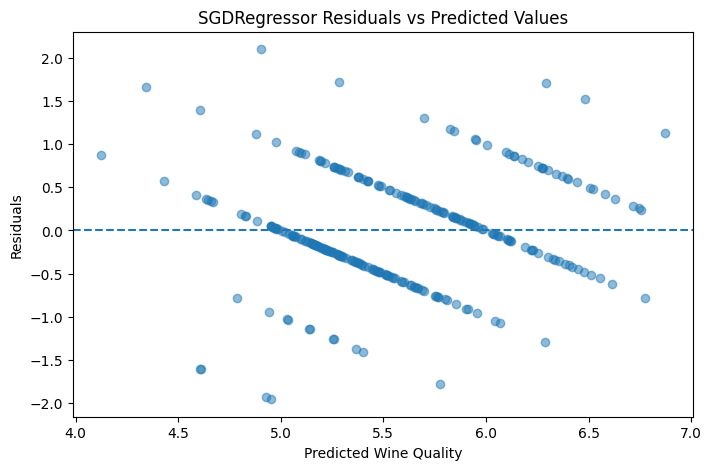

In [67]:
plt.figure(figsize=(8, 5))

plt.scatter(sgd_pred, sgd_residuals, alpha=0.5)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted Wine Quality")
plt.ylabel("Residuals")
plt.title("SGDRegressor Residuals vs Predicted Values")

plt.show()

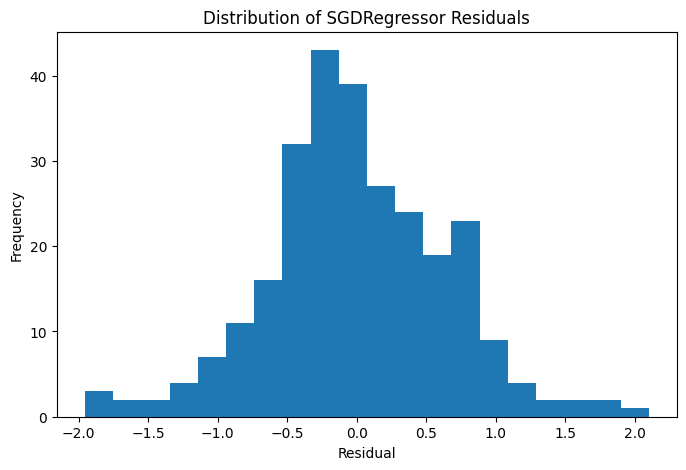

In [68]:
plt.figure(figsize=(8, 5))

plt.hist(sgd_residuals, bins=20)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Distribution of SGDRegressor Residuals")

plt.show()

<Figure size 800x500 with 0 Axes>

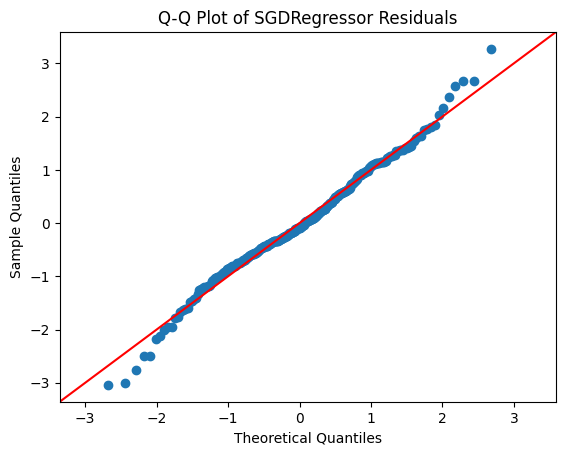

In [69]:
plt.figure(figsize=(8, 5))

sm.qqplot(sgd_residuals, line="45", fit=True)

plt.title("Q-Q Plot of SGDRegressor Residuals")

plt.show()

In [70]:
print("SGD Residual Summary")
print("--------------------")
print(f"Mean residual: {sgd_residuals.mean():.4f}")
print(f"Std residual:  {sgd_residuals.std():.4f}")
print(f"Min residual:  {sgd_residuals.min():.4f}")
print(f"Max residual:  {sgd_residuals.max():.4f}")

SGD Residual Summary
--------------------
Mean residual: -0.0016
Std residual:  0.6431
Min residual:  -1.9532
Max residual:  2.0984


In [71]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

sgd_mse = mean_squared_error(y_test, sgd_pred)
sgd_rmse = np.sqrt(sgd_mse)
sgd_mae = mean_absolute_error(y_test, sgd_pred)
sgd_r2 = r2_score(y_test, sgd_pred)

print("SGDRegressor Test Results")
print("-------------------------")
print(f"MSE:  {sgd_mse:.4f}")
print(f"RMSE: {sgd_rmse:.4f}")
print(f"MAE:  {sgd_mae:.4f}")
print(f"R²:   {sgd_r2:.4f}")

SGDRegressor Test Results
-------------------------
MSE:  0.4121
RMSE: 0.6419
MAE:  0.4974
R²:   0.4182


In [72]:
sgd_train_pred = sgd_model.predict(X_train_scaled)

sgd_train_mse = mean_squared_error(y_train, sgd_train_pred)
sgd_train_rmse = np.sqrt(sgd_train_mse)
sgd_train_mae = mean_absolute_error(y_train, sgd_train_pred)
sgd_train_r2 = r2_score(y_train, sgd_train_pred)

print("SGDRegressor Training Results")
print("-----------------------------")
print(f"MSE:  {sgd_train_mse:.4f}")
print(f"RMSE: {sgd_train_rmse:.4f}")
print(f"MAE:  {sgd_train_mae:.4f}")
print(f"R²:   {sgd_train_r2:.4f}")

SGDRegressor Training Results
-----------------------------
MSE:  0.4633
RMSE: 0.6807
MAE:  0.5282
R²:   0.3077


In [73]:
comparison = pd.DataFrame({
    "Model": [
        "OLS",
        "Regularized OLS",
        "SGDRegressor"
    ],
    "Test MSE": [
        0.4137,
        0.4121,
        sgd_mse
    ],
    "Test RMSE": [
        0.6432,
        0.6420,
        sgd_rmse
    ],
    "Test MAE": [
        0.4981,
        0.4928,
        sgd_mae
    ],
    "Test R²": [
        0.4159,
        0.4182,
        sgd_r2
    ]
})

display(comparison)

,Model,Test MSE,Test RMSE,Test MAE,Test R²
0,OLS,0.41370,0.643200,0.498100,0.415900
1,Regularized OLS,0.41210,0.642000,0.492800,0.418200
2,SGDRegressor,0.41209,0.641942,0.497373,0.418245


In [74]:
ols_pred = ols_model.predict(X_test_sm)

reg_ols_pred = regularized_ols.predict(X_test_sm)

sgd_pred = sgd_model.predict(X_test_scaled)

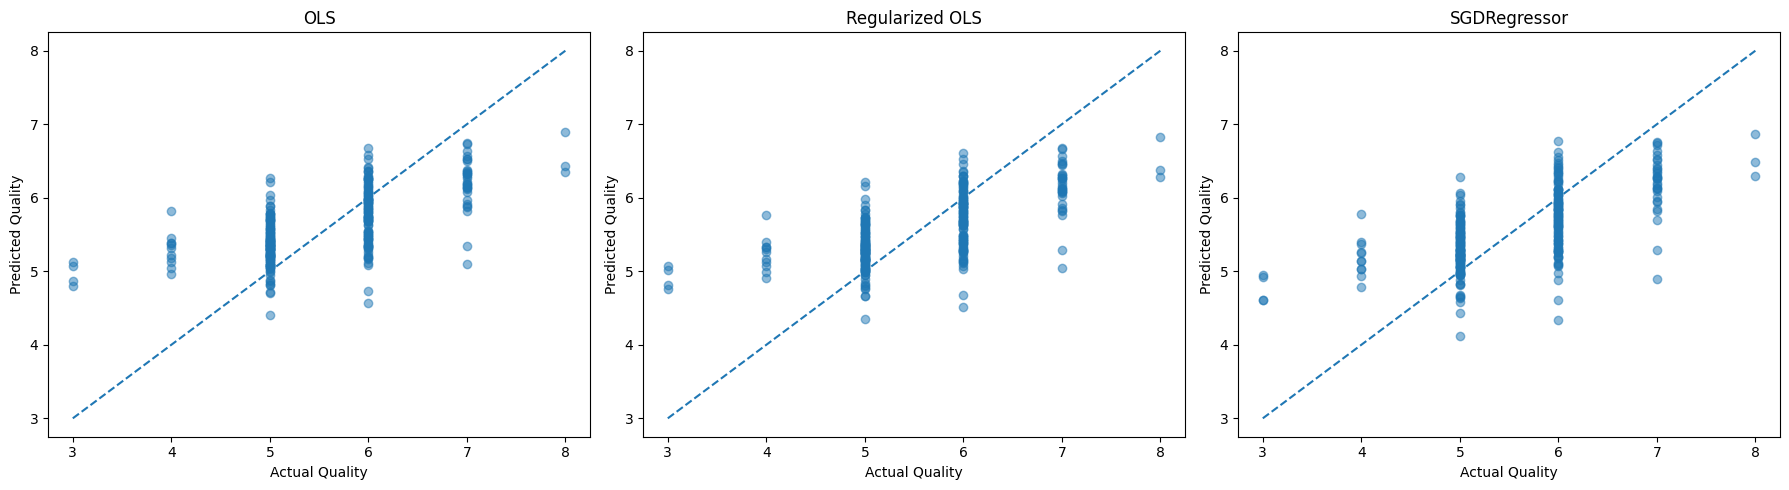

In [75]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# OLS
axes[0].scatter(y_test, ols_pred, alpha=0.5)
axes[0].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)
axes[0].set_title("OLS")
axes[0].set_xlabel("Actual Quality")
axes[0].set_ylabel("Predicted Quality")

# Regularized OLS
axes[1].scatter(y_test, reg_ols_pred, alpha=0.5)
axes[1].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)
axes[1].set_title("Regularized OLS")
axes[1].set_xlabel("Actual Quality")
axes[1].set_ylabel("Predicted Quality")

# SGD
axes[2].scatter(y_test, sgd_pred, alpha=0.5)
axes[2].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)
axes[2].set_title("SGDRegressor")
axes[2].set_xlabel("Actual Quality")
axes[2].set_ylabel("Predicted Quality")

plt.tight_layout()
plt.show()

In [76]:
ols_residuals = y_test - ols_pred
reg_ols_residuals = y_test - reg_ols_pred
sgd_residuals = y_test - sgd_pred

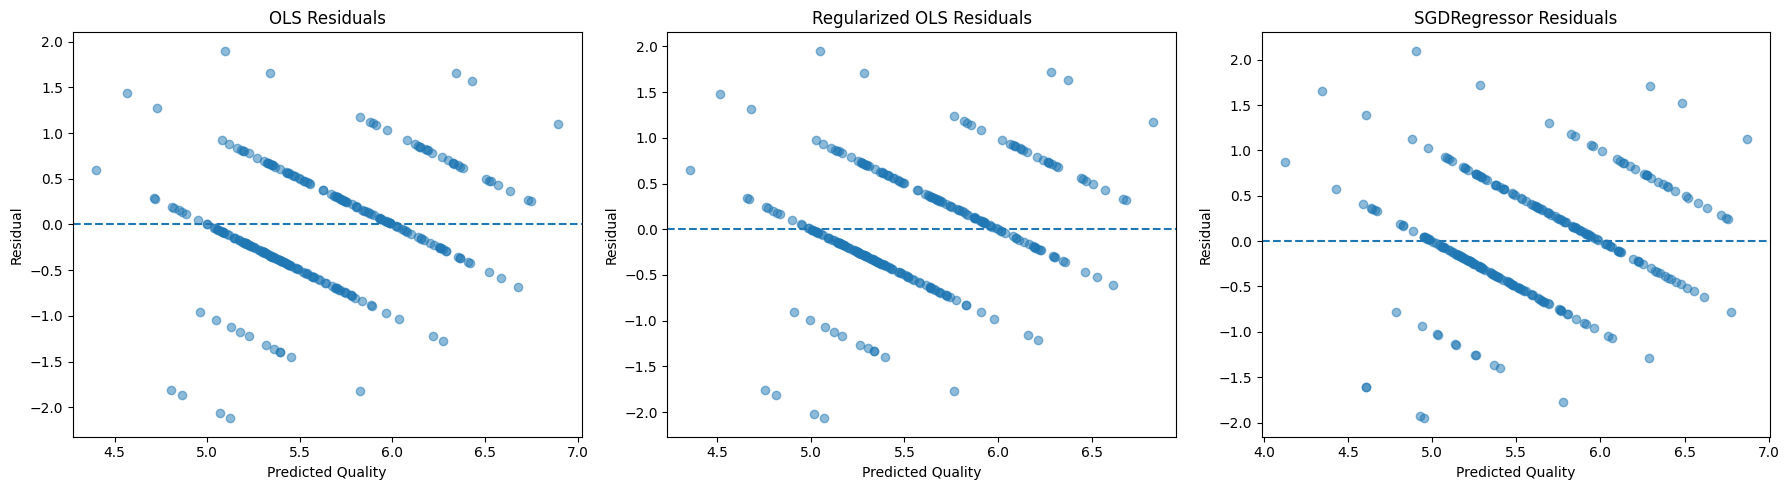

In [77]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(ols_pred, ols_residuals, alpha=0.5)
axes[0].axhline(y=0, linestyle="--")
axes[0].set_title("OLS Residuals")
axes[0].set_xlabel("Predicted Quality")
axes[0].set_ylabel("Residual")

axes[1].scatter(reg_ols_pred, reg_ols_residuals, alpha=0.5)
axes[1].axhline(y=0, linestyle="--")
axes[1].set_title("Regularized OLS Residuals")
axes[1].set_xlabel("Predicted Quality")
axes[1].set_ylabel("Residual")

axes[2].scatter(sgd_pred, sgd_residuals, alpha=0.5)
axes[2].axhline(y=0, linestyle="--")
axes[2].set_title("SGDRegressor Residuals")
axes[2].set_xlabel("Predicted Quality")
axes[2].set_ylabel("Residual")

plt.tight_layout()
plt.show()

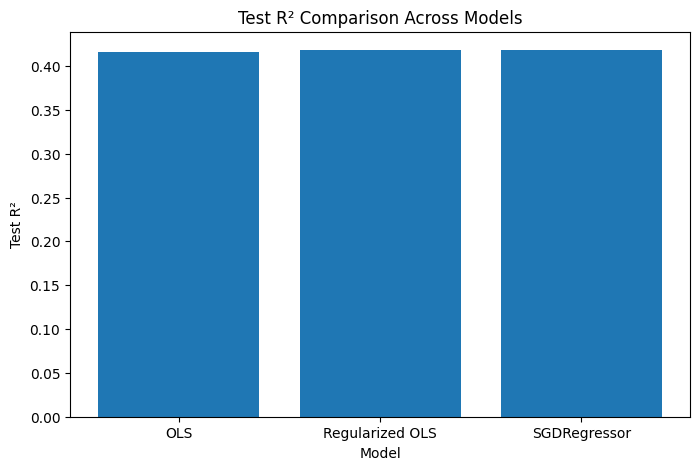

In [78]:
plt.figure(figsize=(8, 5))

models = ["OLS", "Regularized OLS", "SGDRegressor"]
r2_values = [0.4159, 0.4182, sgd_r2]

plt.bar(models, r2_values)

plt.xlabel("Model")
plt.ylabel("Test R²")
plt.title("Test R² Comparison Across Models")

plt.show()

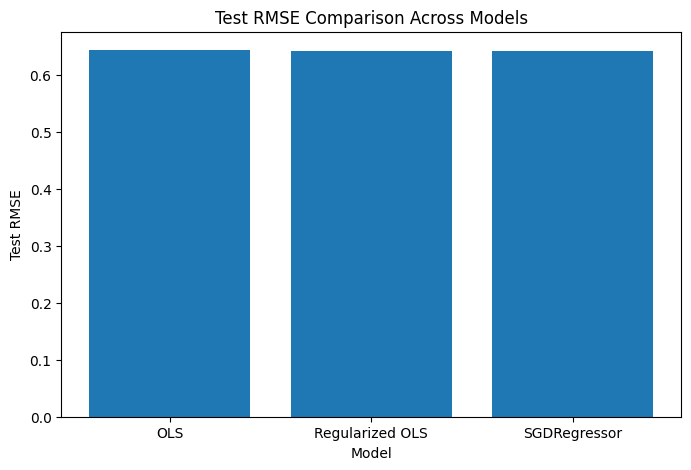

In [79]:
plt.figure(figsize=(8, 5))

rmse_values = [0.6432, 0.6420, sgd_rmse]

plt.bar(models, rmse_values)

plt.xlabel("Model")
plt.ylabel("Test RMSE")
plt.title("Test RMSE Comparison Across Models")

plt.show()

In [80]:
comparison.round(4)

,Model,Test MSE,Test RMSE,Test MAE,Test R²
0,OLS,0.4137,0.6432,0.4981,0.4159
1,Regularized OLS,0.4121,0.6420,0.4928,0.4182
2,SGDRegressor,0.4121,0.6419,0.4974,0.4182
